# M0 — Environment & Scaffold for the Differentiable Elastic-RT Forward Model

**retrieve-or-bust · branch `rt-elastic-prototype` · 2026-07-31**

This notebook explains what milestone **M0** of the elastic-RT coding plan
actually built, and — more usefully — *why each piece is shaped the way it is*.

M0 is deliberately unscientific. It produces no reflectance, fits nothing, and
retrieves no IOPs. Its entire job is to make the next four milestones possible:
a JAX stack that runs, a package skeleton whose public interface is already the
one the design specifies, and a test suite that fails loudly when any of that
stops being true.

**Companion documents**

| Document | Role |
|---|---|
| [`design/rt_elastic_model.md`](../../design/rt_elastic_model.md) | the design — *what / why* |
| [`design/rt_elastic_model_coding_plan.md`](../../design/rt_elastic_model_coding_plan.md) | the plan — *how / when* (milestones M0–M5) |
| [`design/rt_elastic_implementation.md`](../../design/rt_elastic_implementation.md) | the record — *what was actually built* |
| [`claude_prompts/RT/rt_elastic_coding_prompt_1.md`](../../claude_prompts/RT/rt_elastic_coding_prompt_1.md) | the M0 prompt + dated work log + Q&A |

Everything below runs top-to-bottom in the `ocean14` environment. The one
data-dependent section (§7) degrades to a message if the Loisel+2023 files are
not mounted.

## 1. Where M0 sits

The target of the whole effort is one callable:

$$\mathrm{Rrs}(\lambda) \;=\; \underbrace{\mathrm{Rrs}_{\rm ZTT}(a, b_b, B_p, \Omega)}_{\text{analytic, differentiable, interpretable}} \;+\; \underbrace{\Delta \mathrm{Rrs}_{\rm emulator}}_{\text{small learned residual}}$$

The analytic backbone (Twardowski & Tonizzo 2018) carries an *explicit*
phase-function dependence; a small neural network learns only what the backbone
misses. Because that residual is small and smooth, the network stays light and
its extrapolation stays bounded — the argument for a hybrid over a wholly
learned model.

| M | Goal | Status |
|---|---|---|
| **M0** | Environment & scaffold | ✅ **done — this notebook** |
| M1 | Data & conventions (L23 loader, `Rrs↔rrs`, `B_p`) | ⬜ next |
| M2 | ZTT analytic backbone in JAX | ⬜ |
| M3 | Residual emulator + hybrid `forward()` | ⬜ |
| M4 | Validation — *week-1 prototype complete* | ⬜ |
| M5 | Beyond week 1 (HydroLight phase-function runs, BRDF) | ⬜ |

Acceptance is **relative, never a blind number**: the hybrid must beat standard
Gordon on held-out splits. Absolute rRMS and latency get *reported*, not
thresholded. One gate is absolute, though — the gradient-correctness check, and
§4 below is about why it needs care.

## 2. The environment

M0 added `jax`, `flax`, `optax`, and `jaxtyping` to `requirements.txt` and
installed them into `ocean14`. CPU-only, by decision (coding plan CQ5) — not by
accident of hardware.

In [1]:
import importlib
import sys
from pathlib import Path

# This notebook lives in notebooks/RT/. `robust` is not pip-installed in
# `ocean14` (deliberately - see Q1: the JAX stack is declared in
# requirements.txt only), so put the repo root on sys.path. Walking up to the
# directory containing robust/__init__.py keeps this working from anywhere.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'robust' / '__init__.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax

print(f'repo   : {REPO}')
print(f'Python {sys.version.split()[0]}\n')

for name in ['jax', 'jaxlib', 'flax', 'optax', 'jaxtyping',
             'numpy', 'scipy', 'xarray', 'pytest']:
    try:
        mod = importlib.import_module(name)
        print(f'  {name:<10} {getattr(mod, "__version__", "?")}')
    except ImportError:
        print(f'  {name:<10} not installed')

print(f'\ndefault backend : {jax.default_backend()}')
print(f'devices         : {jax.devices()}')

repo   : /Users/xavier/Oceanography/python/retrieve-or-bust
Python 3.14.6

  jax        0.11.0
  jaxlib     0.11.0
  flax       0.12.8
  optax      0.2.8
  jaxtyping  0.3.11
  numpy      2.4.6
  scipy      1.18.0


  xarray     2026.4.0
  pytest     9.1.1

default backend : cpu
devices         : [CpuDevice(id=0)]


Two things about that install worth knowing, because both were checked rather
than hoped for.

**It was purely additive.** The coding plan flagged "JAX might perturb
`ocean14`" as an M0 risk, with a separate `rt-jax` environment as the fallback.
A `pip install --dry-run` *before* touching the environment showed `numpy>=2.1`
and `scipy>=1.15` already satisfied and nothing scheduled for uninstall; after
installing, `ocpy`, `bing`, `emcee`, `scikit-learn` and `matplotlib` all still
import at unchanged versions. So we stay in `ocean14`, and the risk is retired
rather than assumed away.

**`jaxlib` is not listed separately** in `requirements.txt` — `jax` requires the
matching version, so a second unpinned entry would only invite version skew. The
plain PyPI wheel is CPU-only on both macOS arm64 and Linux (a GPU build would be
`jax[cuda12]`), so "CPU-only" needs no extra machinery. The JAX stack is declared
in `requirements.txt` **only**, not in `setup.py`, so `pip install -e .` for
non-RT work never has to pull `jaxlib`.

## 3. Why JAX: the gradient is the product

The design's non-goal is the inversion — but its *guarantee* is that the forward
model is differentiable, so an inversion can later be built on it without
rewriting the physics. That is the whole reason for JAX over NumPy.

To show what that buys, here is the **standard Gordon (1988) relation** — *not*
the model we are building, just a stand-in with the right shape, since M0
implements no physics:

$$u = \frac{b_b}{a + b_b}, \qquad r_{rs} = G_1 u + G_2 u^2, \qquad
  \mathrm{Rrs} = \frac{A\, r_{rs}}{1 - B\, r_{rs}}$$

with $A = 0.52$, $B = 1.7$ (Lee et al. 2002 — the convention `robust.rt` shares
with BING) and the canonical $G_1 = 0.0949$, $G_2 = 0.0794$.

In [2]:
import jax
import jax.numpy as jnp

A_RRS, B_RRS = 0.52, 1.7      # Lee et al. 2002; matches bing.rt.rrs
G1, G2 = 0.0949, 0.0794       # canonical Gordon (1988)


def Rrs_gordon(a, bb):
    '''Standard Gordon Rrs — an illustration, not robust.rt.forward.'''
    u = bb / (a + bb)
    rrs = G1 * u + G2 * u ** 2
    return A_RRS * rrs / (1.0 - B_RRS * rrs)


a0, bb0 = 0.15, 0.006         # a plausible coastal-ish (a, bb) at 440 nm, 1/m

# One call gives the value; one more gives every partial derivative.
dRrs_da, dRrs_dbb = jax.grad(Rrs_gordon, argnums=(0, 1))(a0, bb0)

print(f'Rrs(a={a0}, bb={bb0})  = {Rrs_gordon(a0, bb0):.6f} 1/sr')
print(f'dRrs/da               = {dRrs_da:+.5f}  (more absorption -> less signal)')
print(f'dRrs/dbb              = {dRrs_dbb:+.5f}  (more backscatter -> more signal)')
print(f'ratio |dbb / da|      = {abs(dRrs_dbb / dRrs_da):.1f}x')

Rrs(a=0.15, bb=0.006)  = 0.001972 1/sr
dRrs/da               = -0.01312  (more absorption -> less signal)
dRrs/dbb              = +0.32793  (more backscatter -> more signal)
ratio |dbb / da|      = 25.0x


The signs are the physics: absorption removes photons, backscatter returns them.
The magnitude is the interesting part — at this operating point `Rrs` is ~25×
more sensitive to $b_b$ than to $a$, which is exactly the kind of conditioning
information an inversion needs and a black-box emulator cannot hand you.

Nothing about `jax.grad` here is special to Gordon. When `Rrs_ZTT` lands at M2,
the same one-liner yields $\partial \mathrm{Rrs}/\partial\{a, b_{bp}, B_p,
\theta_s\}$ — and M4 gates those derivatives against finite differences.

## 4. Why float64 is a prerequisite, not a preference

The gradient gate compares `jax.grad` against a **central finite difference**:

$$\frac{\partial \mathrm{Rrs}}{\partial a} \;\approx\;
  \frac{\mathrm{Rrs}(a + h) - \mathrm{Rrs}(a - h)}{2h}$$

That difference subtracts two nearly-equal numbers, so it loses precision as $h$
shrinks while the truncation error grows as $h$ grows — the classic V-shaped
error curve. JAX defaults to **float32**, and at float32 the bottom of that V may
sit above the tolerance you want to gate on.

So: measure it, rather than assert it.

In [3]:
import numpy as np

STEPS = np.logspace(-9, -1, 33)


def fd_error_curve(dtype, steps=STEPS):
    '''Relative error of central-FD dRrs/da vs jax.grad, all math in `dtype`.

    The dtype is pinned on the *arrays* (see the note below) — passing Python
    floats would silently do the arithmetic in float64 and prove nothing.
    '''
    a = jnp.asarray(a0, dtype=dtype)
    bb = jnp.asarray(bb0, dtype=dtype)
    exact = jax.grad(Rrs_gordon, argnums=0)(a, bb)
    assert exact.dtype == dtype, 'dtype did not take'

    errors = []
    for h in steps:
        hh = jnp.asarray(h, dtype=dtype)
        fd = (Rrs_gordon(a + hh, bb) - Rrs_gordon(a - hh, bb)) / (2 * hh)
        errors.append(abs(float(fd) - float(exact)) / abs(float(exact)))
    return np.array(errors), float(exact)


err32, grad32 = fd_error_curve(jnp.float32)

jax.config.update('jax_enable_x64', True)          # what the jax_x64 fixture does
err64, grad64 = fd_error_curve(jnp.float64)
jax.config.update('jax_enable_x64', False)         # ...and restores

TOL = 1e-6                                          # a gate worth having
print(f'best relative error   float32 {err32.min():.2e}   float64 {err64.min():.2e}')
print(f'step sizes meeting {TOL:.0e}:  float32 {(err32 < TOL).sum():2d}/{len(STEPS)}'
      f'        float64 {(err64 < TOL).sum():2d}/{len(STEPS)}')
print(f'\ndtype after restore: {jnp.ones(3).dtype}  (global flag put back)')

best relative error   float32 1.19e-05   float64 8.50e-12
step sizes meeting 1e-06:  float32  0/33        float64 21/33

dtype after restore: float32  (global flag put back)


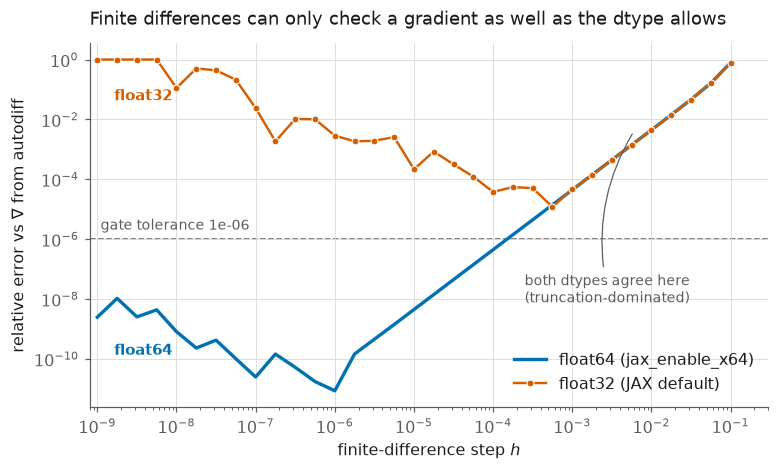

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- house style: recessive frame, ink-coloured text, one figure = one idea ---
INK, INK_MUTED, GRID = '#1a1a1a', '#5c5c5c', '#dcdcdc'
C32, C64 = '#D55E00', '#0072B2'   # CVD-checked pair: OKLab dE 28.8-44.8 (>= 8)

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10.5,
    'axes.edgecolor': INK_MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(7.2, 4.4))

# float64 as a bare line, float32 as line+markers on top: for h > ~1e-3 the two
# coincide (truncation dominates, dtype is irrelevant), and without this the
# orange would simply vanish under the blue and look like missing data.
ax.loglog(STEPS, err64, color=C64, lw=2.2, label='float64 (jax_enable_x64)',
          zorder=2)
ax.loglog(STEPS, err32, color=C32, lw=1.6, marker='o', ms=4.5,
          markeredgecolor='white', markeredgewidth=0.7,
          label='float32 (JAX default)', zorder=3)

ax.axhline(TOL, color=INK_MUTED, lw=1, ls='--', zorder=1)
ax.text(1.1e-9, TOL * 1.6, f'gate tolerance {TOL:.0e}', color=INK_MUTED,
        fontsize=9, va='bottom')

# Direct labels at the LEFT ends, where the curves are far apart. (At the right
# edge both converge, so labels there would overprint each other.)
ax.annotate('float32', xy=(STEPS[0], err32[0]), xytext=(11, -19),
            textcoords='offset points', color=C32, fontsize=10,
            va='top', fontweight='bold')
ax.annotate('float64', xy=(STEPS[0], err64[0]), xytext=(11, -17),
            textcoords='offset points', color=C64, fontsize=10,
            va='top', fontweight='bold')
ax.annotate('both dtypes agree here\n(truncation-dominated)',
            xy=(6e-3, 4e-3), xytext=(2.5e-4, 2e-8), color=INK_MUTED,
            fontsize=9, ha='left', va='center',
            arrowprops=dict(arrowstyle='-', color=INK_MUTED, lw=0.8,
                            connectionstyle='arc3,rad=-0.2'))

ax.set_xlabel('finite-difference step $h$')
ax.set_ylabel(r'relative error vs $\nabla$ from autodiff')
ax.set_title('Finite differences can only check a gradient as well as the dtype allows',
             fontsize=11.5, pad=12, loc='left')
ax.legend(loc='lower right')
ax.set_xlim(8e-10, 3e-1)
fig.tight_layout()
plt.show()

Read the V from the right: as $h$ shrinks both curves fall (less truncation
error), until cancellation takes over and they climb again. The two floors are
about six orders of magnitude apart.

The practical consequence is sharper than "float32 is less accurate". At a
tolerance of $10^{-6}$ — a reasonable bar for *"is this gradient correct?"* —
**float32 passes at none of the 33 step sizes, float64 at 21 of them.** A gate in
float32 would have to be either loosened to ~$10^{-4}$ or tuned to one lucky $h$;
in float64 it passes across three decades of $h$, so the check tests the
gradient rather than the step size. That is why `robust/tests/conftest.py` ships
a `jax_x64` fixture, and why it *restores* the flag afterwards: `jax_enable_x64`
is global, and a leaked change would quietly alter the dtype regime of every
test that ran later.

> **A trap worth recording.** The first version of the cell above passed Python
> floats to `Rrs_gordon`. Python floats are float64 and the function body is pure
> arithmetic, so *both* curves were secretly computed in float64 and the
> "float32" one came out ~1e-7 — nonsense that looks like good news. The dtype
> has to be pinned on the arrays. When M2 writes the real FD gate, the same trap
> is waiting: a float64 perturbation around a float32 model silently tests
> something other than what you meant.

## 5. The scaffold: interface now, physics later

`robust/rt/` exists in full, module for module, as the coding plan lays it out.
Most modules are documentation only; two carry their **final public signatures**
already and raise `NotImplementedError` naming the milestone that will fill them.

The point is that the interface is fixed from day one, so M1–M4 fill in bodies
instead of renegotiating the API — while nothing can mistake a stub for working
physics.

In [5]:
from robust import rt

# What lands at which milestone - the scaffold's whole content in one view.
MILESTONE = {
    'rt/__init__.py': 'M0  submodule imports + forward() re-export',
    'rt/conventions.py': 'M1  A/B, wavelength grid, bb_w, asserts',
    'rt/types.py': 'M1  IOPs / PhaseParams / Geometry pytrees',
    'rt/data/__init__.py': 'M0  re-exports l23',
    'rt/data/l23.py': 'M1  L23 elastic batches + seeded splits',
    'rt/ztt.py': 'M2  Rrs_ZTT - signature pinned, body pending',
    'rt/emulator.py': 'M3  Flax MLP dRrs + Optax training',
    'rt/hybrid.py': 'M3  forward() - signature + MODES pinned',
    'rt/validation.py': 'M4  rRMS / speed / gradient protocol',
    'tests/__init__.py': 'M0',
    'tests/conftest.py': 'M0  needs_l23 marker, jax_x64 fixture',
    'tests/test_env.py': 'M0  12 tests - the gate',
}

for sub in ('rt', 'tests'):
    print(f'robust/{sub}/')
    for path in sorted((REPO / 'robust' / sub).rglob('*.py')):
        key = str(path.relative_to(REPO / 'robust'))
        print(f'  {key:<22} {path.stat().st_size:>5,d} B   {MILESTONE.get(key, "")}')
    print()

robust/rt/
  rt/__init__.py         1,915 B   M0  submodule imports + forward() re-export
  rt/conventions.py        865 B   M1  A/B, wavelength grid, bb_w, asserts
  rt/data/__init__.py      357 B   M0  re-exports l23
  rt/data/l23.py         1,291 B   M1  L23 elastic batches + seeded splits
  rt/emulator.py         1,016 B   M3  Flax MLP dRrs + Optax training
  rt/hybrid.py           1,773 B   M3  forward() - signature + MODES pinned
  rt/types.py            1,139 B   M1  IOPs / PhaseParams / Geometry pytrees
  rt/validation.py       1,331 B   M4  rRMS / speed / gradient protocol
  rt/ztt.py              2,171 B   M2  Rrs_ZTT - signature pinned, body pending

robust/tests/
  tests/__init__.py         81 B   M0
  tests/conftest.py      2,536 B   M0  needs_l23 marker, jax_x64 fixture
  tests/test_env.py      4,531 B   M0  12 tests - the gate



In [6]:
import inspect

# Every module of the planned layout is present and re-exported.
print('robust.rt exports :', [n for n in rt.__all__])
print('robust.rt.data    :', rt.data.__all__)

print('\nThe public entry point, with its final signature:')
print('  forward', inspect.signature(rt.forward))
print('  Rrs_ZTT', inspect.signature(rt.ztt.Rrs_ZTT))
print('\nThe three comparable configurations (design 4.5):', rt.hybrid.MODES)

robust.rt exports : ['conventions', 'types', 'data', 'ztt', 'emulator', 'hybrid', 'validation', 'forward']
robust.rt.data    : ['l23']

The public entry point, with its final signature:
  forward (iops, phase_params, geometry, wave, mode='hybrid')
  Rrs_ZTT (iops, phase_params, geometry, wave)

The three comparable configurations (design 4.5): ('ztt', 'emulator', 'hybrid')


In [7]:
# A stub must never return a plausible-looking array. It raises, and says when
# it will stop raising. A test in test_env.py asserts exactly this.
for label, fn in [('rt.forward', rt.forward), ('rt.ztt.Rrs_ZTT', rt.ztt.Rrs_ZTT)]:
    try:
        fn(None, None, None, None)
    except NotImplementedError as exc:
        print(f'{label:<16} -> NotImplementedError: {exc}')

rt.forward       -> NotImplementedError: forward lands in M3 (see design/rt_elastic_model_coding_plan.md); mode='hybrid'
rt.ztt.Rrs_ZTT   -> NotImplementedError: Rrs_ZTT lands in M2 (see design/rt_elastic_model_coding_plan.md)


One nicety of the stub stage: `from robust import rt` currently imports **no**
heavy dependency — not even `jax` — because none of the stubs has a module-level
import. That changes the moment M2 puts `import jax.numpy` at `ztt.py`'s module
scope, which is expected and recorded, so the slowdown is not later mistaken for
a regression. `emulator.py` is documented to import `flax`/`optax` *inside* its
functions, so the analytic-only path never pays for the ML stack.

## 6. The gate

Every milestone is `pytest`-gated. M0's gate asks for two things: `import jax`
works on CPU, and `from robust import rt` succeeds. The suite has 12 tests
instead of 2, on purpose — the extras are the properties *later* milestones
depend on, so a broken install surfaces now rather than three milestones in.

In [8]:
import subprocess
import sys

result = subprocess.run([sys.executable, '-m', 'pytest', '-q'],
                        cwd=REPO, capture_output=True, text=True)
print(result.stdout[-1500:] or result.stderr[-1500:])

............                                                             [100%]
12 passed in 0.54s



What those 12 cover, and why each earns its place:

| Group | Tests | Why |
|---|---|---|
| JAX | `ones(3)` on CPU; **every** device is CPU; float64 reachable; the x64 fixture restores; `grad`; `jit`; `flax`/`optax` import | CQ5 is CPU-only, so an accelerator sneaking in should fail, not surprise us at M4's throughput numbers. `jit` is checked because the design requires `jit`/`vmap`-friendliness — a broken XLA should fail here, not at M3. |
| `robust.rt` | import; every planned module present + `forward` callable; both stubs raise; `MODES` declared | Keeps the scaffold honest: the stub cannot quietly start returning zeros. |
| Data | `l23_available()` returns a bool without raising; `ocpy`'s L23 loader imports | It gates every M1+ data test, so it must never be the thing that breaks. |

`robust/tests/conftest.py` holds the two pieces of shared machinery, both aimed
at M1 and beyond:

In [9]:
import os

from robust.tests.conftest import L23_ELASTIC_FILES, l23_available

print('elastic files the prototype needs :', L23_ELASTIC_FILES)
print('$OS_COLOR                         :', os.getenv('OS_COLOR'))
print('l23_available()                   :', l23_available())

elastic files the prototype needs : ('Hydrolight100.nc', 'Hydrolight130.nc', 'Hydrolight160.nc')
$OS_COLOR                         : /Users/xavier/Projects/Oceanography/data/Color/
l23_available()                   : True


1. **`l23_available()` + the `needs_l23` marker.** The Loisel+2023 files are
   ~17 MB each, live outside the repo, and are found via `$OS_COLOR`. From M1 on,
   data-dependent tests declare that once and **absence becomes a skip, not a
   failure** — so `pytest -q` stays meaningful on a machine without the dataset.
   The approach is lifted from BING's `conftest.py` (reuse, not reinvention),
   narrowed to the three elastic files. Verified by pointing `OS_COLOR` at a
   nonexistent path: the probe returns `False` instead of raising, and all 12
   tests still pass.
2. **The `jax_x64` fixture**, for the reason §4 spent a figure on.

## 7. A look at the reference data (preview of M1)

Nothing below is M0 work — the loader is M1's job. But it is worth seeing what
the prototype will be scored against, and confirming the files are in hand.

The elastic set is `Hydrolight1{Y:02d}.nc` (X=1 → no inelastic processes) at
three solar-zenith angles, $Y \in \{0°, 30°, 60°\}$: **3320 scenes × 81
wavelengths**, nadir view, fixed Fournier–Forand phase function. Solar zenith is
therefore the one geometry axis the week-1 prototype can genuinely exercise —
sensor angle and phase-function *shape* wait for M5's new HydroLight runs. The
design is explicit about that limitation rather than quiet about it.

In [10]:
HAVE_DATA = l23_available()

if not HAVE_DATA:
    print('L23 files not mounted ($OS_COLOR) - skipping the data preview.')
else:
    from ocpy.hydrolight import loisel23

    ds = loisel23.load_ds(1, 0)           # X=1 elastic, Y=0 deg solar zenith
    wave = ds.Lambda.data
    Rrs = ds.Rrs.data
    a440 = ds.a.data[:, np.argmin(abs(wave - 440))]
    B_p = (ds.bbnw.data / ds.bnw.data)[:, np.argmin(abs(wave - 440))]

    print(f'dims        : {dict(ds.sizes)}')
    print(f'wavelengths : {wave.min():.0f}-{wave.max():.0f} nm, {wave.size} bands')
    print(f'a(440)      : {a440.min():.4f} to {a440.max():.4f} 1/m')
    print(f'B_p(440)    : {np.percentile(B_p, [1, 50, 99]).round(4)} '
          f'(1st / 50th / 99th pct)')
    print(f'\ndesign expects B_p in ~[0.004, 0.03]: '
          f'{"consistent" if 0.004 <= np.median(B_p) <= 0.03 else "CHECK THIS"}')

dims        : {'IOP_Scenario': 3320, 'Lambda': 81}
wavelengths : 350-750 nm, 81 bands
a(440)      : 0.0087 to 0.9974 1/m
B_p(440)    : [0.0105 0.0126 0.018 ] (1st / 50th / 99th pct)

design expects B_p in ~[0.004, 0.03]: consistent


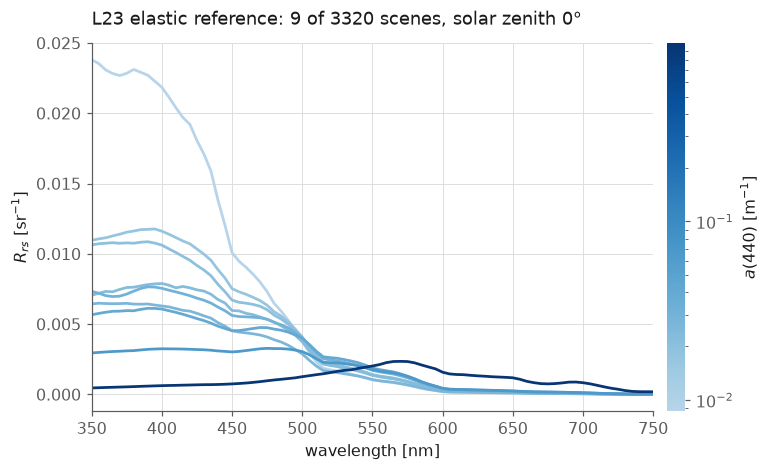

In [11]:
if not HAVE_DATA:
    print('L23 files not mounted - skipping the figure.')
else:
    # Sequential magnitude -> ONE hue, light to dark. Truncated so the lightest
    # line still has contrast against a white surface.
    n_show = 9
    idx = np.argsort(a440)[np.linspace(0, len(a440) - 1, n_show).astype(int)]
    ramp = mpl.colors.LinearSegmentedColormap.from_list(
        'blues_trunc', plt.cm.Blues(np.linspace(0.30, 0.98, 256)))
    norm = mpl.colors.LogNorm(vmin=a440[idx].min(), vmax=a440[idx].max())

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for i in idx:
        ax.plot(wave, Rrs[i], lw=1.8, color=ramp(norm(a440[i])))

    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=ramp), ax=ax,
                        pad=0.02)
    cbar.set_label('$a$(440) [m$^{-1}$]', color=INK)
    cbar.outline.set_visible(False)

    ax.set_xlabel('wavelength [nm]')
    ax.set_ylabel('$R_{rs}$ [sr$^{-1}$]')
    ax.set_title(f'L23 elastic reference: {n_show} of 3320 scenes, '
                 'solar zenith 0°', fontsize=11.5, pad=12, loc='left')
    ax.set_xlim(wave.min(), wave.max())
    fig.tight_layout()
    plt.show()

Clear water (light) peaks in the blue and collapses in the red; as absorption
rises (dark) the peak flattens and shifts green. Reproducing this family — from
$a$, $b_b$, $B_p$ and geometry, differentiably, faster than HydroLight — is the
whole assignment.

Note the vertical scale: `Rrs` in the red is smaller than in the blue by more
than an order of magnitude. That is precisely why M3 trains the emulator on a
**relatively weighted** objective. Unweighted, the fit would be dominated by the
blue and the red would be free to run away — the lesson BING already paid for.

## 8. Where this leaves us

**M0 is complete.** `pytest -q` → 12 passed; `ruff check robust/` → clean; the
suite is green with *and* without the reference data on disk.

What exists: a CPU JAX stack verified in `ocean14`, `robust/rt/` with every
module of the planned layout and two final public signatures pinned,
`robust/tests/` in BING layout with the L23 skip machinery and the x64 fixture,
and [`design/rt_elastic_implementation.md`](../../design/rt_elastic_implementation.md)
(v0.3) as the structured record.

What deliberately does not exist yet: any physics. `forward` raises.

**Next — M1 (data & conventions).** `conventions.py` (`A=0.52`, `B=1.7`, the
81-band grid, `bb_w(λ)`, load-time asserts), the `IOPs`/`PhaseParams`/`Geometry`
pytrees, and the L23 batch loader with $B_p = b_{bnw}/b_{nw}$ and the seeded
splits (random 20 % of scenes; hold out the 60° zenith). Its gate: shape and
range checks, an `Rrs→rrs→Rrs` round trip to 1e-6, and a golden value pinned
against the raw netCDF. All three files it needs are already on disk, as §7 just
confirmed.

**One open question for JXP** (Q2 in the prompt's Q&A): this repo has no ruff
config, so `ruff check` currently runs against whatever the installed ruff
defaults to. Worth pinning a `ruff.toml` — and deciding on `ruff format`, which
would rewrite quote style package-wide — before M1 adds real code. Neither
blocks M1.